In [1]:
%reset -f
#Sliding FFT in Python!
###############################
#Import the necessary libraries
import numpy as np
import os
import matplotlib.image as mpimg
from skimage import color
from scipy import fftpack
from scipy import ndimage
from pysptools.eea import nfindr
import pysptools.abundance_maps as amp
#import eea
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn import decomposition
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
#%%Functions%%
def LoadFile(full_path):
    #Loads the file from the path full_path
    #Returns the image after conversion to grayscale

    imgsrc = color.rgb2gray(mpimg.imread(full_path));
    return imgsrc

def ApplyHamming(imgsrc):
    #Applies a Hamming window to the input imgsrc, returns the window after filter applied.
    window_size=imgsrc.shape[0]
    bw2d = np.outer(np.hamming(window_size), np.ones(window_size))
    bw2d = np.sqrt(bw2d * bw2d.T) 
    imgout = imgsrc*bw2d
    return imgout
    
def MakeWindow(imgsrc, xpos, ypos):
    #Returns the portion of the image within the window given the
    #image (imgsrc), the xposition and the yposition
    imgpatch = imgsrc[xpos:xpos+window_size, ypos:ypos+window_size]
    return imgpatch

def GenerateXYPos(window_size, window_step, image_width, image_height):   
    #Generates the (x,y) pairs given the window size, window step and image width  and height
    xpos_vec = np.arange(0,image_width-window_size,window_step)
    ypos_vec = np.arange(0,image_height-window_size,window_step)
    num_stepsX = len(xpos_vec)
    num_stepsY = len(ypos_vec)
    pos_mat = np.zeros((num_stepsX*num_stepsY,2),dtype=np.int16)
    for i in range(0, num_stepsX):
        for j in range(0,num_stepsY):
            pos_mat[(i*num_stepsY+j),:]=(xpos_vec[i],ypos_vec[j])
    #pos_mat = np.column_stack((xpos_mat, ypos_mat))
              
    return (pos_mat, num_stepsX,num_stepsY)

def zoom_interpol(FFT_image):   
    #Accepts an image, returns zoomed image
    zoom_size = (FFT_image.shape[0]/FFT_zoom_factor)/2
    if np.mod(FFT_image.shape[0]/FFT_zoom_factor,2)==0:
        F2_zoomed= FFT_image[int(window_size/2 - zoom_size):int(window_size/2 + zoom_size), 
                             int(window_size/2 - zoom_size):int(window_size/2 +zoom_size)]
    else:                    
        F2_zoomed= FFT_image[int(window_size/2 - zoom_size):int(window_size/2+1 + zoom_size), 
                             int(window_size/2 - zoom_size):int(window_size/2 + 1+zoom_size)]
    
    return ndimage.zoom(F2_zoomed,interpol_factor)
    
def zoom_discrete(FFT_image,new_size):
    #Accepts an image, returns zoomed image of a given pixel size
    F2_zoomed=FFT_image[int((window_size-new_size)/2):int((window_size+new_size)/2),
        int((window_size-new_size)/2):int((window_size+new_size)/2)]
    return  F2_zoomed
    
def plot_FFT_window(FFT_final, option):   #1 for normal, option is str defining plot type
    plt.figure()
    plt.cla()

    if option =='log':
        plt.imshow(np.log(abs(FFT_final)), interpolation = 'none')    
        
    elif option =='sqrt':
        plt.imshow(np.sqrt(abs(FFT_final)), interpolation = 'none')    

    else:
        plt.imshow(abs(FFT_final), interpolation = 'none')    
        
def Do_Sliding_FFT():
    #Carries out the FFT
    FFT_mat4 = np.zeros((sizeX*sizeY, int(window_size*interpol_factor/FFT_zoom_factor), int(window_size*interpol_factor/FFT_zoom_factor)))
    for  i in range(0,sizeX*sizeY):
        img_window = MakeWindow(raw_image, pos_mat[i,0], pos_mat[i,1]) #Generate the window on which FFT is performed                     
        #Pass the x and y positions of the top-left corner of the FFT window
        #These positions are located in pos_mat
        if hamming_filter ==1: #Apply filter if requested
            img_window_filtered = ApplyHamming(np.copy(img_window))
        else:
            img_window_filtered = (np.copy(img_window))
        
        # Take the fourier transform of the image.
        F1 = fftpack.fft2((img_window_filtered),shape=None, axes=None, overwrite_x=False) 
        
        # Now shift so that low spatial frequencies are in the center.
        F2 = (fftpack.fftshift((F1)))
       
        final_FFT = zoom_interpol(np.abs(F2))
        
        FFT_mat4[i,:,:,] =final_FFT
        if ((i%1000)==0): print(i)

    return FFT_mat4

def Do_Sliding_FFT_discrete():
    #Carries out the FFT for fixed window size
    FFT_mat4 = np.zeros((sizeX*sizeY, new_size, new_size), dtype=np.complex64)
    for  i in range(0,sizeX*sizeY):
        img_window = MakeWindow(raw_image, pos_mat[i,0], pos_mat[i,1]) #Generate the window on which FFT is performed                     
        #Pass the x and y positions of the top-left corner of the FFT window
        #These positions are located in pos_mat
        if hamming_filter ==1: #Apply filter if requested
            img_window_filtered = ApplyHamming(np.copy(img_window))
        else:
            img_window_filtered = (np.copy(img_window))
        
        # Take the fourier transform of the image.
        F1 = fftpack.fft2((img_window_filtered),shape=None, axes=None, overwrite_x=False) 
        
        # Now shift so that low spatial frequencies are in the center.
        F2 = (fftpack.fftshift((F1)))
       
        final_FFT=zoom_discrete(F2, new_size)
        
        FFT_mat4[i,:,:,] =final_FFT
        if ((i%1000)==0): print(i)

    return FFT_mat4

    
def analyze_endmembers(FFT_mat, num_comp):
    #Determines endmembers given the 3D FFT matrix.
    #Analyzes results by NFINDR
    #Plots the results and saves to .png files


    #Find endmembers and abundance maps
    ne = num_comp #Number of endmembers
    
    q = FFT_mat.shape
    a = q[0]
    b = q[1]
    c = q[2]
    d = q[3]
    
    data_mat3 = FFT_mat.reshape((a*b, c*d))
    data_mat3 = np.abs(data_mat3)
    
    nnls = amp.FCLS()
    a1 = nfindr.NFINDR(data_mat3, ne) #Find endmembers
    endmembers = a1[0]
    
    data_mat3 = data_mat3.reshape((a,b, c*d))
    amap = nnls.map(data_mat3, endmembers) #Find abundances
    
    #Do plotting
    fig301, axes301 = plt.subplots(4, 3, figsize=(10, 10))
    
    indices = np.arange(0,ne)
    endmembers = endmembers.reshape(ne, c, d) 

    for ax, index in zip(axes301.flat, indices):
        im = ax.imshow(np.sqrt(endmembers[index,:,:]), interpolation = 'none' )
        ax.set_title('Endmember: %d' %(index+1))
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.08) #space for colorbar
        plt.tick_params(axis='x', which='both', bottom='off',top='off',labelbottom='off')                
        plt.tick_params(axis='y', which='both', bottom='off',top='off',labelbottom='off')
        plt.colorbar(im, cax = cax)
        plt.tight_layout()
            
        
    fig302, axes302 = plt.subplots(4, 3, figsize=(10, 10))
    
    for ax, index in zip(axes302.flat, indices):
        im = ax.imshow(np.flipud(np.rot90(amap[:,:,index])), interpolation = 'none')
        ax.set_title('Abundance: %d' %(index+1))
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.08) #space for colorbar
        plt.tick_params(axis='x', which='both', bottom='off',top='off',labelbottom='off')                
        plt.tick_params(axis='y', which='both', bottom='off',top='off',labelbottom='off')            
        plt.colorbar(im, cax = cax)
        plt.tight_layout()

    fig303, axes303 = plt.subplots(4, 3, figsize=(10, 10))
    
    for ax, index in zip(axes303.flat, indices):
        amap_endm = np.copy(amap[:,:,index])                            
        amap_full_sum = np.sum(amap[:,:,0:],2)
        amap_error = amap_endm - amap_full_sum
        im = ax.imshow(np.flipud(np.rot90(amap_error)), interpolation = 'none')
        ax.set_title('Error: %d' %(index+1))
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.08) #space for colorbar                 
        plt.tick_params(axis='x', which='both', bottom='off',top='off',labelbottom='off')                
        plt.tick_params(axis='y', which='both', bottom='off',top='off',labelbottom='off')                                 
        plt.colorbar(im, cax = cax)            
        plt.tight_layout()                
        
    return endmembers, amap

def do_PCA(FFT_mat):
    #Find endmembers and abundance maps  
    q = FFT_mat.shape
   
    a = q[0]
    b = q[1]
    c = q[2]
    d = q[3]
    
    data_mat3 = FFT_mat.reshape((a*b, c*d))
    data_mat3 = np.real(data_mat3)
    
    U, S, V = np.linalg.svd(data_mat3, full_matrices = False, compute_uv = True)
    
    
    e_vecs = S*V.T
    e_vecs = e_vecs.T
    
    e_vecs = e_vecs.reshape(a*b, c, d)
    e_vals = U.reshape((a,b, a*b))
    
    ##Plot PCA Results
    #Plot eigenvectors
    fig201, axes201 = plt.subplots(3, 3, figsize=(12, 12))
    fig201.subplots_adjust(hspace=0.3, wspace=0.3)
    fig201.suptitle("PCA Components")
    
    indices = np.arange(0,9)
    
    for ax, index in zip(axes201.flat, indices):
        im=ax.imshow((e_vecs[index,:,:]))
        ax.set_title('PCA Component: %d' %(index+1))
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05) #space for colorbar
        plt.colorbar(im, cax = cax)
        
    plt.show()
    #Now Plot eigenvalues
    fig202, axes202 = plt.subplots(3, 3, figsize=(12, 12))
    fig202.subplots_adjust(hspace=0.4, wspace=0.4)
    fig202.suptitle("PCA Loadings")
    
    for ax, index in zip(axes202.flat, indices):
           
        im = ax.imshow(np.flipud(np.rot90(e_vals[:,:, index])), interpolation = 'none')
        ax.set_title('Loading: %d' %(index+1))
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05) #space for colorbar
        plt.colorbar(im, cax = cax)
        
    plt.show()    
    
    fig203 = plt.figure()
    axes203 = fig203.add_axes([0.1, 0.1, .8, .8]) # left, bottom, width, height (range 0 to 1)
    axes203.semilogy(S, 'b')
    axes203.set_xlabel('Principal Component')
    axes203.set_ylabel('Eigenvalues Squared')
    axes203.set_title('Scree Plot')
    
    plt.show() 
    
    return e_vecs, e_vals
                
def do_ICA(FFT_mat, num_comp):
    #Find components  
    q = FFT_mat.shape
   
    a = q[0]
    b = q[1]
    c = q[2]
    d = q[3]
    
    data_mat3 = FFT_mat.reshape((a*b, c*d))
    data_mat3 = np.real(data_mat3)
    
    ica = decomposition.FastICA(n_components=num_comp)
    rec_ica = ica.fit_transform(data_mat3) # do the ICA
    
    ica_comp = ica.components_      # get the components
    
    rec_ica = rec_ica.reshape(a,b,-1)  #mixing coefficeints
    ica_comp = ica_comp.reshape(-1,c,d) 
       
    ##Plot ICA Results
    #Plot eigenvectors
    if num_comp <5:
        fig401, axes401 = plt.subplots(2, 2, figsize=(12, 12))
        fig402, axes402 = plt.subplots(2, 2, figsize=(12, 12))
    
    else:
        fig401, axes401 = plt.subplots(3, 3, figsize=(12, 12))    
        fig402, axes402 = plt.subplots(3, 3, figsize=(12, 12))
        
    fig401.subplots_adjust(hspace=0.3, wspace=0.3)
    fig401.suptitle("ICA Components")
    
    indices = np.arange(0,num_comp)
    
    for ax, index in zip(axes401.flat, indices):
        ax.imshow(ica_comp[index,:])
        ax.set_title('ICA Component: %d' %(index+1))
        
    plt.show()
    
    #Now Plot mixing maps
    fig402.subplots_adjust(hspace=0.4, wspace=0.4)
    fig402.suptitle("ICA Mixing Coefficients")
    cp = plt.cm.jet
    
    for ax, index in zip(axes402.flat, indices):
           
        im = ax.imshow(rec_ica[:,:,index], cmap = cp, interpolation = 'none')
        divider = make_axes_locatable(ax)
        # Append axes to the right of ax3, with 10% width of ax
        cax = divider.append_axes("right", size="10%", pad=0.05)
        
        plt.colorbar(im, cax = cax, format="%.2f")
        ax.set_title('Mixing: %d' %(index+1))
       
    plt.show() 

    return ica_comp, rec_ica
 

def do_NMF(FFT_mat, num_comp):
    #Find components  
    q = FFT_mat.shape
   
    a = q[0]
    b = q[1]
    c = q[2]
    d = q[3]
    
    data_mat3 = FFT_mat.reshape((a*b, c*d))
    data_mat3=data_mat3.astype(np.float32)
    data_mat3 = np.abs(data_mat3)
    
    model = NMF(n_components=num_comp, init='random', random_state=0, max_iter=400)
    nmf_amap = model.fit_transform(data_mat3)
    nmf_comp = model.components_
    nmf_comp = nmf_comp.reshape((num_comp,c,d))                       
    
    data_mat3 = data_mat3.reshape((a,b, c*d))
    
    #Find abundances
    nmf_amap = nmf_amap.reshape(a,b,num_comp)
    #fcls = amp.NNLS() #For abundance calculation
    #nmf_amap = fcls.map(data_mat3, nmf_comp.reshape(num_comp, c*d)) #Find abundances
        
    
    ##Plot NMF Results
    #Plot components
    if num_comp <5:
        fig501, axes501 = plt.subplots(2, 2, figsize=(12, 12))
        fig502, axes502 = plt.subplots(2, 2, figsize=(12, 12))
    elif num_comp==6:
        fig501, axes501 = plt.subplots(2, 3, figsize=(12, 12))
        fig502, axes502 = plt.subplots(2, 3, figsize=(12, 12))
    else:
        fig501, axes501 = plt.subplots(8, 3, figsize=(12, 12))    
        fig502, axes502 = plt.subplots(8, 3, figsize=(12, 12))
        
    fig501.subplots_adjust(hspace=0.3, wspace=0.3)
    fig501.suptitle("NMF Components")
    
    indices = np.arange(0,num_comp)
    
    for ax, index in zip(axes501.flat, indices):
        im=ax.imshow(nmf_comp[index,:])
        ax.set_title('NMF Component: %d' %(index+1))
        divider = make_axes_locatable(ax)
        # Append axes to the right of ax3, with 10% width of ax
        cax = divider.append_axes("right", size="10%", pad=0.05)
        plt.colorbar(im, cax = cax, format="%.2f")
    
    
    #Now Plot mixing maps
    fig502.subplots_adjust(hspace=0.4, wspace=0.4)
    fig502.suptitle("NMF Coefficients")
    cp = plt.get_cmap('viridis')
    
    for ax, index in zip(axes502.flat, indices):
           
        im = ax.imshow(np.flipud(np.rot90(nmf_amap[:,:,index])), cmap = cp, interpolation = 'none')
        divider = make_axes_locatable(ax)
        # Append axes to the right of ax3, with 10% width of ax
        cax = divider.append_axes("right", size="10%", pad=0.05)
        
        plt.colorbar(im, cax = cax, format="%.2f")
        ax.set_title('Mixing: %d' %(index+1))
       
    
    fig501.tight_layout()
    fig502.tight_layout()
    
    return nmf_comp, nmf_amap   

In [9]:
%cd "C:\\Users\\ayb\\Merlin\\test\\Jun24_26"
filename = "SuperScan (HAADF) 2.npy" #filename of image to analyze
#num_of_comp = 16 #Number of endmembers for NFINDR
window_size = 128 # #x=y sizes for sliding window
window_step = 4 # #x=y sizes of each step
hamming_filter = 1 #1 for use of hamming window
FFT_zoom_factor = 2 #Zoom factor for FFT
new_size=63
#interpol_factor = 1 #Factor for interpolation

C:\Users\ayb\Merlin\test\Jun24_26


In [10]:
%cd "C:\\Users\\ayb\\Merlin\\test\\Jun24_26"
raw_image = np.load(filename) #Loads image
(pos_mat, sizeX, sizeY) = GenerateXYPos(window_size, window_step, raw_image.shape[0], raw_image.shape[1]) #Generate matrix with (x,y) locations of window position
print(sizeX*sizeY)
FFT_mat4 = Do_Sliding_FFT_discrete() #Do the Sliding FFT   
FFT_mat5 = FFT_mat4.reshape(sizeX, sizeY, new_size, new_size)                          
                                    
    

C:\Users\ayb\Merlin\test\Jun24_26
230400
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
1

In [ ]:
#Separate analysis from array generation to facilitate multiple tries with different # of comps
#NFINDR block
plt.close('all')
num_of_comp = 4 #Number of endmembers
endmembers, amap = analyze_endmembers(FFT_mat5, num_of_comp) 
%cd "D:\Albina\work\data\JWeber_images\July_2025"
np.save(os.path.join(cur_dir, '32_256_8_4_endmembers_fine'), endmembers)
for index in range(0, num_of_comp):
    np.save(os.path.join(cur_dir, '32_256_8_4_fineendmember%d' %(index+1)), endmembers[index,:,:])

#np.save(os.path.join(cur_dir, '37A_6_FFT_matfine'), FFT_mat5)
for index in range(0, num_of_comp):
    np.save(os.path.join(cur_dir, '32_256_8_4_fineamap%d' %(index+1)), np.flipud(np.rot90(amap[:,:,index])))

In [ ]:
#Separate analysis from array generation to facilitate multiple tries with different # of comps
#NFINDR block
plt.close('all')
num_of_comp = 6 #Number of endmembers
endmembers, amap = analyze_endmembers(FFT_mat5, num_of_comp) 

In [ ]:
#Separate analysis from array generation to facilitate multiple tries with different # of comps
#PCA block
plt.close('all')
num_of_comp = 6 #Number of endmembers
e_vecs, e_vals=do_PCA(FFT_mat5)
for index in range (0,9):
    np.save(os.path.join(cur_dir, 'PCA_evec%d' %(index+1)), e_vecs[index,:,:])
    np.save(os.path.join(cur_dir, 'PCA_eval%d' %(index+1)), np.flipud(np.rot90(e_vals[:,:, index])))

C:\Users\ayb\Merlin\test\Jun24_26


C:\Users\ayb\AppData\Local\Temp\ipykernel_19436\3754357046.py:324: ComplexWarning: Casting complex values to real discards the imaginary part
  data_mat3=data_mat3.astype(np.float32)
C:\Users\ayb\Main\Lib\site-packages\sklearn\decomposition\_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 400 reached. Increase it to improve convergence.
  warnings.warn(
C:\Users\ayb\AppData\Local\Temp\ipykernel_19436\3754357046.py:363: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1200 with 25 Axes> than <Figure size 1200x1200 with 24 Axes> which fig.colorbar is called on.
  plt.colorbar(im, cax = cax, format="%.2f")
C:\Users\ayb\AppData\Local\Temp\ipykernel_19436\3754357046.py:363: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1200 with 26 Axes> than <Figure size 1200x1200 with 24 Axes> which fig.colorbar is called on.
  plt.colorbar(im, cax = cax, format="%.2f")
C:\Users\ayb\AppData\Local\Temp\ipykernel_19436\3754357046.py:363: UserWarning: 

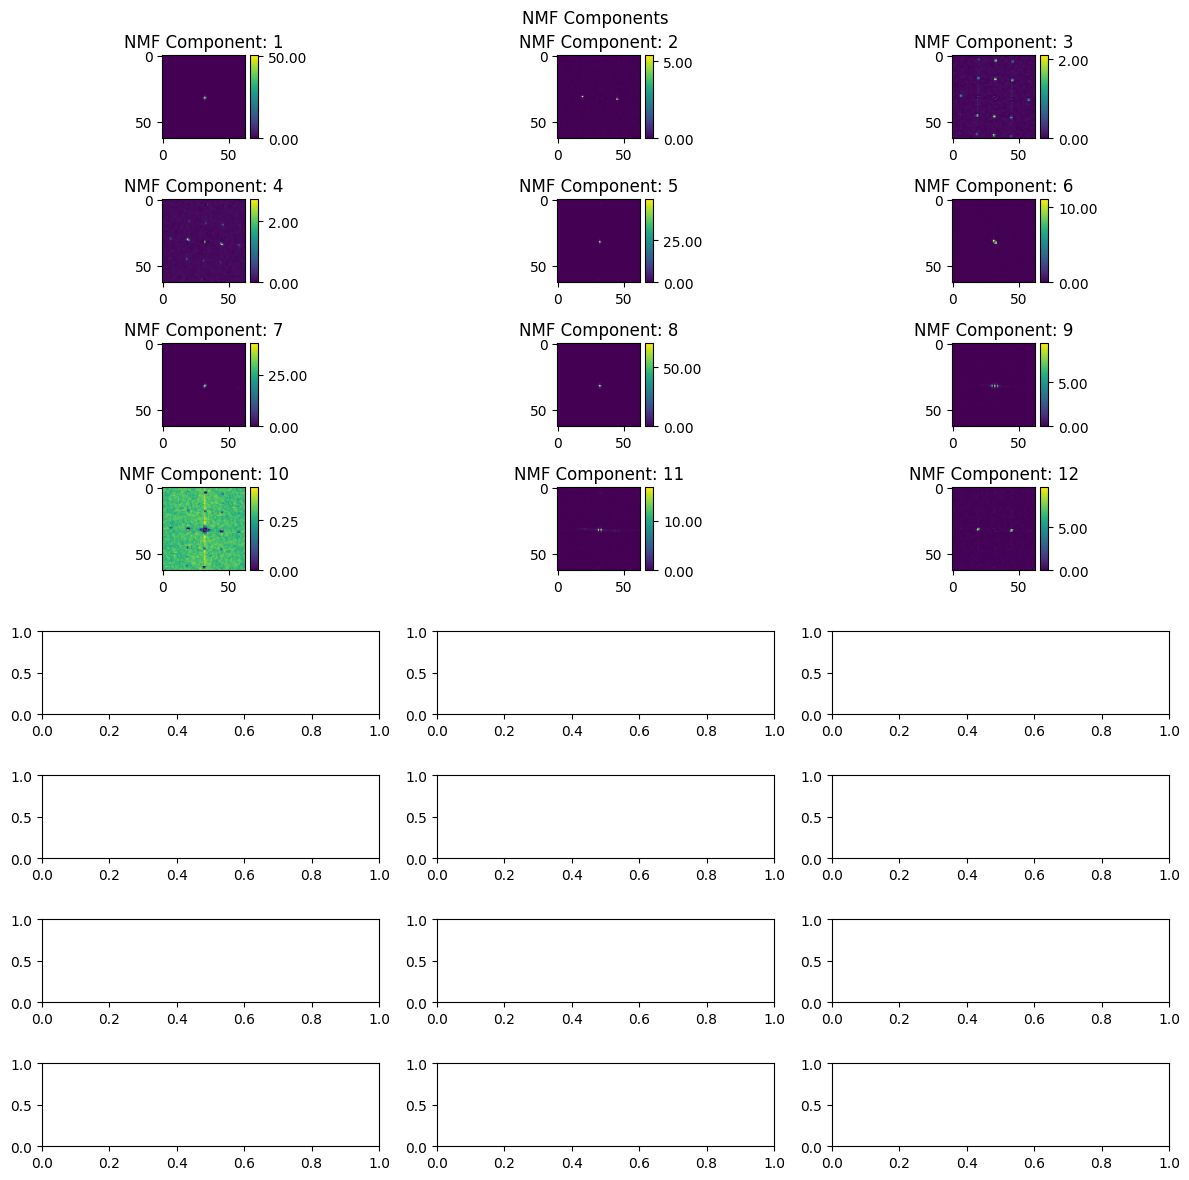

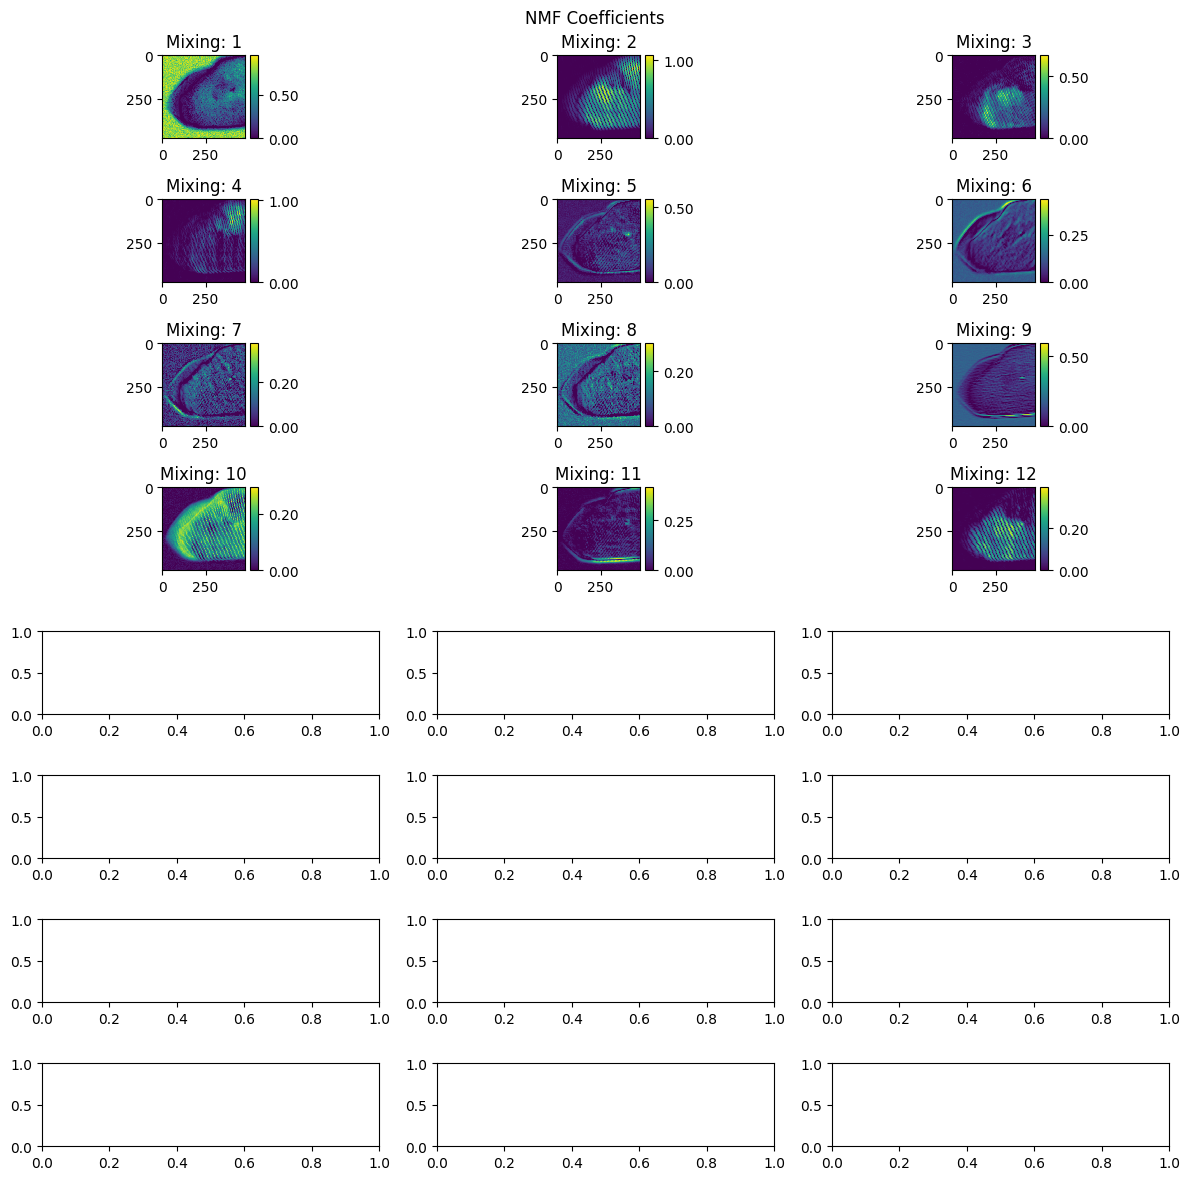

In [13]:
#Separate analysis from array generation to facilitate multiple tries with different # of comps
#NMF block
%cd "C:\\Users\\ayb\\Merlin\\test\\Jun24_26"
plt.close('all')
num_of_comp = 12 #Number of endmembers
nmf_comps, nmf_abundances = do_NMF(FFT_mat5,num_of_comp)
np.save('02_ADF_128_4_2_12comps', nmf_comps)
for index in range(0, num_of_comp):
    np.save(('02_ADF_128_4_2_12comps_abund%d' %(index+1)), np.flipud(np.rot90(nmf_abundances[:,:,index])))
    

In [ ]:
#Separate analysis from array generation to facilitate multiple tries with different # of comps
#ICA block
plt.close('all')
num_of_comp = 6 #Number of endmembers
ica_comps, mixing_coefs = do_ICA(FFT_mat5, num_of_comp)
np.save(os.path.join(cur_dir, 'ICA_comps'), ica_comps)
for index in range(0, num_of_comp):
    np.save(os.path.join(cur_dir, 'ICA_mixing%d' %(index+1)), np.flipud(np.rot90(mixing_coefs[:,:,index])))
    